# Example Usage DACCAS

This notebook demonstrates examples of how DACCAS can be used. For each of the 5 addressed CAPTCHAs, we demonstrate the pipeline including classification and solving. It is also demonstrated what happens in the case the puzzle type is not known.

### 1. Import DACCAS

In [1]:
from daccas import DACCAS

### 2. Load the system

When integrating DACCAS in a crawler/scraper, make sure to put this line before starting the crawl. This prevents that DACCAS has to be loaded during the crawl which can take some time.

In [3]:
daccas = DACCAS(models_dir="models", charsets_dir="charsets", device="cpu", preload=True)

The classifier can be ran with:
```python
daccas.Classify("filepath/to/your/image.png")
```
The solver can be ran with:
```python
daccas.Solve("filepath/to/your/image.png", "class_of_your_image")
```

These two can be combined in two ways <br>
Method 1: first run the classifier, and use the predicted class as argument in the solver
```python
cls = daccas.Classify("filepath/to/your/image.png")
daccas.Solve("filepath/to/your/image.png", cls["class"])
```

Method 2: let DACCAS do the whole pipeline itself
```python
daccas.run("filepath/to/your/image.png")
```

### 3. Example use cases

This section assumes that you have some example test images. You should change the path in the cell below to where you have stored the images. These are just regular images that could be obtained from the provided datasets (from their test set of course, so the model has not seen them).

If you want to use the exact same images, one can obtain the SYSTEM_TEST folder images from the dataset directory

In [54]:
# Just to show the image to you, not needed for the pipeline
from PIL import Image, ImageDraw
from IPython.display import display

test_images_dir = "../../../Downloads/SYSTEM_TEST"

### 3.1 Text CAPTCHAs

#### Gregwar

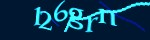

In [25]:
Image.open(f"{test_images_dir}/GREGWAR_TEST.jpg")

In [26]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/GREGWAR_TEST.jpg")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution: {result["result"]["text"]}")

Predicted Class: Text (Gregwar)
Predicted Solution: 126grn


#### Mobicms

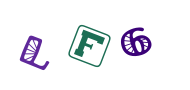

In [27]:
Image.open(f"{test_images_dir}/MOBICMS_TEST.png")

In [29]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/MOBICMS_TEST.png")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution: {result["result"]["text"]}")

Predicted Class: Text (Mobicms)
Predicted Solution: lf6


#### General

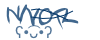

In [31]:
Image.open(f"{test_images_dir}/TEXT_OTHER_TEST.jpg")

In [32]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/TEXT_OTHER_TEST.jpg")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution: {result["result"]["text"]}")

Predicted Class: Text (Other)
Predicted Solution: NNOR


#### King Market

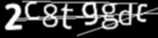

In [34]:
Image.open(f"{test_images_dir}/KING_TEST.png")

In [35]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/KING_TEST.png")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution: {result["result"]["text"]}")

Predicted Class: Text (King)
Predicted Solution: 2c8t9gdc


### 3.2 Moving Window

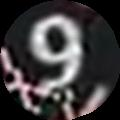

In [37]:
Image.open(f"{test_images_dir}/MOVING_WINDOW.jpg")

In [40]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/MOVING_WINDOW.jpg")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution: {result["result"]["character"]}")

Predicted Class: Moving Window
Predicted Solution: 9


### 3.3 Open Circle

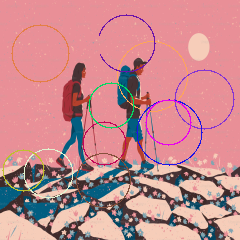

In [50]:
oc_img = Image.open(f"{test_images_dir}/OPEN_CIRCLE_TEST.png")
draw = ImageDraw.Draw(oc_img)
oc_img

In [48]:
# Classify and Solve it
result = daccas.run(f"{test_images_dir}/OPEN_CIRCLE_TEST.png")
print(f"Predicted Class: {result["classification"]["class"]}")
print(f"Predicted Solution (x, y): ({result["result"]["x"]}, {result["result"]["y"]})")
print(f"Full bounding box (x1, y1, x2, y2): {result["result"]["all_boxes"][0]["xyxy"]}")

Predicted Class: Open Circle
Predicted Solution (x, y): (126.1789779663086, 42.959842681884766)
Full bounding box (x1, y1, x2, y2): [97.00028991699219, 13.861572265625, 155.357666015625, 72.05811309814453]


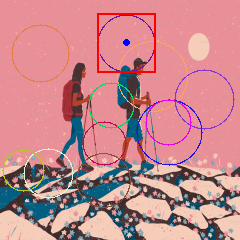

In [52]:
# Show that the prediction is correct
box = result["result"]["all_boxes"][0]["xyxy"]
draw.rectangle([box[0], box[1], box[2], box[3]], outline="red", width=2)
draw.ellipse(
    [result["result"]["x"] - 3, result["result"]["y"] - 3, result["result"]["x"] + 3, result["result"]["y"] + 3],
    fill="blue",
    outline="blue"
)
oc_img

### 3.4a Image Rotation (Default)

This one assumes that you have the differently rotated variants already in one directory together, in which the files can be easily obtained in a loop.

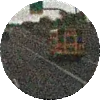

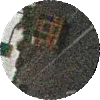

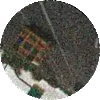

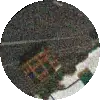

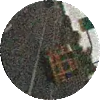

In [57]:
# the number of rotated variants
n_variants = 5
for i in range(1, n_variants+1):
    rot_img = Image.open(f"{test_images_dir}/IMAGE_ROTATION_DEFAULT_V{i}.png")
    display(rot_img)

In [61]:
# Classify and Solve it
best_p = -1
best_image = None
for i in range (1,n_variants+1):
    result = daccas.run(f"{test_images_dir}/IMAGE_ROTATION_DEFAULT_V{i}.png")
    print(f"Predicted Class for image {i}: {result["classification"]["class"]}")
    print(f"Predicted upright score: {result["result"]["p_upright"]}")
    if result["result"]["p_upright"] > best_p:
        best_p = result["result"]["p_upright"]
        best_image = i
print("-"*60)
print(f"The Predicted Solution is: IMAGE_ROTATION_DEFAULT_V{best_image}.png with a highest probability of {best_p}")

Predicted Class for image 1: Image Rotation (Default)
Predicted upright score: 0.31900868877594063
Predicted Class for image 2: Image Rotation (Default)
Predicted upright score: 0.001833515888470193
Predicted Class for image 3: Image Rotation (Default)
Predicted upright score: 0.0002747655940887194
Predicted Class for image 4: Image Rotation (Default)
Predicted upright score: 0.003418777783105681
Predicted Class for image 5: Image Rotation (Default)
Predicted upright score: 0.0009439698922206454
------------------------------------------------------------
The Predicted Solution is: IMAGE_ROTATION_DEFAULT_V1.png with a highest probability of 0.31900868877594063


### 3.4b Image Rotation Special

This one assumes that you have the differently rotated variants already in one directory together, in which the files can be easily obtained in a loop.

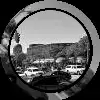

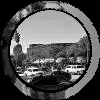

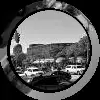

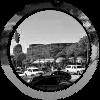

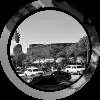

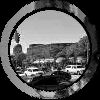

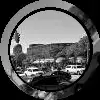

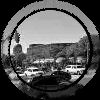

In [62]:
# the number of rotated variants
n_variants = 8
for i in range(1, n_variants+1):
    rot_img = Image.open(f"{test_images_dir}/IMAGE_ROTATION_SPECIAL_V{i}.png")
    display(rot_img)

In [65]:
# Classify and Solve it
best_sobel = float("inf")
best_image = None
for i in range (1,n_variants+1):
    result = daccas.run(f"{test_images_dir}/IMAGE_ROTATION_SPECIAL_V{i}.png")
    print(f"Predicted Class for image {i}: {result["classification"]["class"]}")
    print(f"Predicted Sobel score: {result["result"]["sobel_score"]}")
    if result["result"]["sobel_score"] < best_sobel:
        best_sobel = result["result"]["sobel_score"]
        best_image = i
print("-"*60)
print(f"The Predicted Solution is: IMAGE_ROTATION_SPECIAL_V{best_image}.png with a lowest Sobel score of {best_sobel}")

Predicted Class for image 1: Image Rotation (Special)
Predicted Sobel score: 368407.84375
Predicted Class for image 2: Image Rotation (Special)
Predicted Sobel score: 400637.1875
Predicted Class for image 3: Image Rotation (Special)
Predicted Sobel score: 447553.0625
Predicted Class for image 4: Image Rotation (Special)
Predicted Sobel score: 476427.375
Predicted Class for image 5: Image Rotation (Special)
Predicted Sobel score: 472681.71875
Predicted Class for image 6: Image Rotation (Special)
Predicted Sobel score: 435653.59375
Predicted Class for image 7: Image Rotation (Special)
Predicted Sobel score: 396178.9375
Predicted Class for image 8: Image Rotation (Special)
Predicted Sobel score: 343146.6875
------------------------------------------------------------
The Predicted Solution is: IMAGE_ROTATION_SPECIAL_V8.png with a lowest Sobel score of 343146.6875
